In [5]:
import tensorflow as tf
import requests
import zipfile
import os
import shutil
import random


In [6]:

MS_URL = 'https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip'
ZIP_PATH = 'kagglecatsanddogs_5340.zip'
RAW_DIR = 'PetImages_raw'
FILTERED_DIR = 'cats_and_dogs_filtered'

# --- Step 1: Download (no auth needed, works with plain requests) ---
if not os.path.exists(ZIP_PATH):
    print("Downloading (~786MB, may take a few minutes)...")
    response = requests.get(MS_URL, stream=True)
    response.raise_for_status()
    with open(ZIP_PATH, 'wb') as f:
        for chunk in response.iter_content(chunk_size=1024 * 1024):
            f.write(chunk)
    print("Download complete.")
else:
    print("Zip already exists, skipping download.")

# --- Step 2: Extract ---
if not os.path.exists(RAW_DIR):
    print("Extracting (this creates a PetImages/Cat and PetImages/Dog folder)...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(RAW_DIR)
    print("Extraction complete.")

cat_src = os.path.join(RAW_DIR, 'PetImages', 'Cat')
dog_src = os.path.join(RAW_DIR, 'PetImages', 'Dog')

# --- Step 3: Build the filtered 2000-image subset with train/validation split ---
random.seed(42)

def valid_images(folder, n):
    """Grab n valid (non-corrupt, non-zero-byte) jpg filenames from folder."""
    files = [f for f in os.listdir(folder) if f.lower().endswith('.jpg')]
    random.shuffle(files)
    picked = []
    for f in files:
        full_path = os.path.join(folder, f)
        if os.path.getsize(full_path) > 0:
            picked.append(f)
        if len(picked) == n:
            break
    return picked

def build_split(src_dir, class_name, n_train, n_val):
    files = valid_images(src_dir, n_train + n_val)
    train_files = files[:n_train]
    val_files = files[n_train:]

    train_out = os.path.join(FILTERED_DIR, 'train', class_name)
    val_out = os.path.join(FILTERED_DIR, 'validation', class_name)
    os.makedirs(train_out, exist_ok=True)
    os.makedirs(val_out, exist_ok=True)

    for f in train_files:
        shutil.copy(os.path.join(src_dir, f), os.path.join(train_out, f))
    for f in val_files:
        shutil.copy(os.path.join(src_dir, f), os.path.join(val_out, f))

if not os.path.exists(FILTERED_DIR):
    print("Building filtered subset (1000 train / 500 val per class)...")
    build_split(cat_src, 'cats', 1000, 500)
    build_split(dog_src, 'dogs', 1000, 500)
    print("Filtered subset ready.")
else:
    print("Filtered subset already exists, skipping.")

# --- Step 4: Confirm ---
train_dir = os.path.join(FILTERED_DIR, 'train')
validation_dir = os.path.join(FILTERED_DIR, 'validation')
train_cats_dir = os.path.join(train_dir, 'cats')
train_dogs_dir = os.path.join(train_dir, 'dogs')

print("Dataset ready at:", FILTERED_DIR)
print("Num train cat images:", len(os.listdir(train_cats_dir)))
print("Num train dog images:", len(os.listdir(train_dogs_dir)))

Download complete.
Extracting (this creates a PetImages/Cat and PetImages/Dog folder)...
Extraction complete.
Building filtered subset (1000 train / 500 val per class)...
Filtered subset ready.
Dataset ready at: cats_and_dogs_filtered
Num train cat images: 1000
Num train dog images: 1000


In [14]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

IMG_SIZE = (150, 150)
BATCH_SIZE = 20

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    validation_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

class_names = train_dataset.class_names
print("Classes:", class_names)  # should print ['cats', 'dogs']

Found 1863 files belonging to 2 classes.
Found 927 files belonging to 2 classes.
Classes: ['cats', 'dogs']


In [16]:
normalization_layer = layers.Rescaling(1./255)

train_dataset = train_dataset.map(lambda x, y: (normalization_layer(x), y))
validation_dataset = validation_dataset.map(lambda x, y: (normalization_layer(x), y))

# Prefetch for performance
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)

In [17]:
model = models.Sequential([
    layers.Input(shape=(150, 150, 3)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),
    layers.Dropout(0.5),          # helps reduce overfitting
    layers.Dense(512, activation='relu'),
    layers.Dense(1, activation='sigmoid')   # binary output: cat=0, dog=1
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,453,121 (13.17 MB)

 Trainable params: 3,453,121 (13.17 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
model.compile(
    loss='binary_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    metrics=['accuracy']
)

In [19]:
history = model.fit(
    train_dataset,
    epochs=15,
    validation_data=validation_dataset
)

Epoch 1/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 36s 348ms/step - accuracy: 0.4858 - loss: 0.6932 - val_accuracy: 0.4962 - val_loss: 0.6932
Epoch 2/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 35s 364ms/step - accuracy: 0.4949 - loss: 0.6932 - val_accuracy: 0.5038 - val_loss: 0.6931
Epoch 3/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 35s 372ms/step - accuracy: 0.4895 - loss: 0.6932 - val_accuracy: 0.4962 - val_loss: 0.6931
Epoch 4/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 35s 371ms/step - accuracy: 0.5051 - loss: 0.6932 - val_accuracy: 0.4962 - val_loss: 0.6931
Epoch 5/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 43s 453ms/step - accuracy: 0.4890 - loss: 0.6933 - val_accuracy: 0.4962 - val_loss: 0.6932
Epoch 6/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 64s 255ms/step - accuracy: 0.4997 - loss: 0.6933 - val_accuracy: 0.4962 - val_loss: 0.6932
Epoch 7/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 25s 261ms/step - accuracy: 0.4933 - loss: 0.6932 - val_accuracy: 0.4962 - val_loss: 0.6931
Epoch 8/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 40s 251ms/step - accuracy: 0.5013 - loss: 0.6931 - val_accu

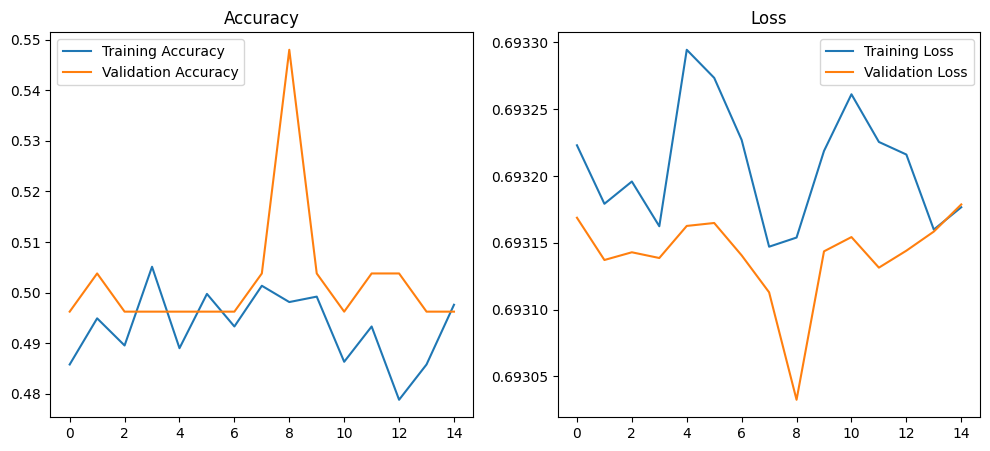

In [20]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title('Loss')

plt.show()

In [12]:
import os

FILTERED_DIR = 'cats_and_dogs_filtered'
num_skipped = 0

for subset in ('train', 'validation'):
    for class_name in ('cats', 'dogs'):
        folder_path = os.path.join(FILTERED_DIR, subset, class_name)
        for fname in os.listdir(folder_path):
            fpath = os.path.join(folder_path, fname)
            try:
                with open(fpath, 'rb') as fobj:
                    is_jfif = b'JFIF' in fobj.peek(10)
            except Exception:
                is_jfif = False

            if not is_jfif:
                num_skipped += 1
                os.remove(fpath)

print(f"Deleted {num_skipped} corrupt/invalid images")

Deleted 210 corrupt/invalid images
